In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/raw/campus_energy.csv")

df.head()

,Timestamp,Building,Building_Type,Energy_kWh,Temperature,Humidity,Occupancy,Holiday,Exam_Day,Weekend,Solar_Output,Equipment_Load,Carbon_Emission,Cost
0,2025-01-01 00:00:00,Hostel_A,Hostel,597.89,30.59,80.23,122,0,1,0,0.0,23,490.27,4783.11
1,2025-01-01 00:00:00,Hostel_B,Hostel,722.20,30.59,80.23,392,0,1,0,0.0,28,592.21,5777.64
2,2025-01-01 00:00:00,Block_A,Classroom,468.98,30.59,80.23,150,0,1,0,0.0,26,384.56,3751.83
3,2025-01-01 00:00:00,Block_B,Classroom,521.69,30.59,80.23,313,0,1,0,0.0,6,427.79,4173.53
4,2025-01-01 00:00:00,AI_Lab,Lab,750.05,30.59,80.23,211,0,1,0,0.0,79,615.04,6000.43


In [3]:
df.shape

(87600, 14)

In [6]:
# df.dtypes
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df.dtypes

Timestamp          datetime64[us]
Building                      str
Building_Type                 str
Energy_kWh                float64
Temperature               float64
Humidity                  float64
Occupancy                   int64
Holiday                     int64
Exam_Day                    int64
Weekend                     int64
Solar_Output              float64
Equipment_Load              int64
Carbon_Emission           float64
Cost                      float64
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 87600 entries, 0 to 87599
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Timestamp        87600 non-null  datetime64[us]
 1   Building         87600 non-null  str           
 2   Building_Type    87600 non-null  str           
 3   Energy_kWh       87600 non-null  float64       
 4   Temperature      87600 non-null  float64       
 5   Humidity         87600 non-null  float64       
 6   Occupancy        87600 non-null  int64         
 7   Holiday          87600 non-null  int64         
 8   Exam_Day         87600 non-null  int64         
 9   Weekend          87600 non-null  int64         
 10  Solar_Output     87600 non-null  float64       
 11  Equipment_Load   87600 non-null  int64         
 12  Carbon_Emission  87600 non-null  float64       
 13  Cost             87600 non-null  float64       
dtypes: datetime64[us](1), float64(6), int64(5), str(2

In [8]:
df.isnull().sum()

Timestamp          0
Building           0
Building_Type      0
Energy_kWh         0
Temperature        0
Humidity           0
Occupancy          0
Holiday            0
Exam_Day           0
Weekend            0
Solar_Output       0
Equipment_Load     0
Carbon_Emission    0
Cost               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,Timestamp,Energy_kWh,Temperature,Humidity,Occupancy,Holiday,Exam_Day,Weekend,Solar_Output,Equipment_Load,Carbon_Emission,Cost
count,87600,87600.000000,87600.000000,87600.000000,87600.000000,87600.000000,87600.000000,87600.000000,87600.000000,87600.000000,87600.000000,87600.000000
mean,2025-07-02 11:30:00,526.093523,28.013137,64.978565,209.389406,0.034475,0.078539,0.284932,18.322061,29.514372,431.396700,4208.748224
min,2025-01-01 00:00:00,170.760000,14.630000,31.850000,20.000000,0.000000,0.000000,0.000000,0.000000,5.000000,140.030000,1366.120000
25%,2025-04-02 05:45:00,411.620000,25.267500,58.137500,115.000000,0.000000,0.000000,0.000000,0.000000,16.000000,337.530000,3292.960000
50%,2025-07-02 11:30:00,503.635000,27.960000,64.880000,209.000000,0.000000,0.000000,0.000000,0.000000,26.000000,412.980000,4029.055000
75%,2025-10-01 17:15:00,646.020000,30.700000,71.802500,304.000000,0.000000,0.000000,1.000000,38.172500,36.000000,529.740000,5168.155000
max,2025-12-31 23:00:00,920.070000,43.920000,107.090000,399.000000,1.000000,1.000000,1.000000,98.740000,99.000000,754.450000,7360.540000
std,NaN,142.732517,3.988131,10.087505,109.451210,0.182447,0.269019,0.451384,22.341869,20.305450,117.040651,1141.860005


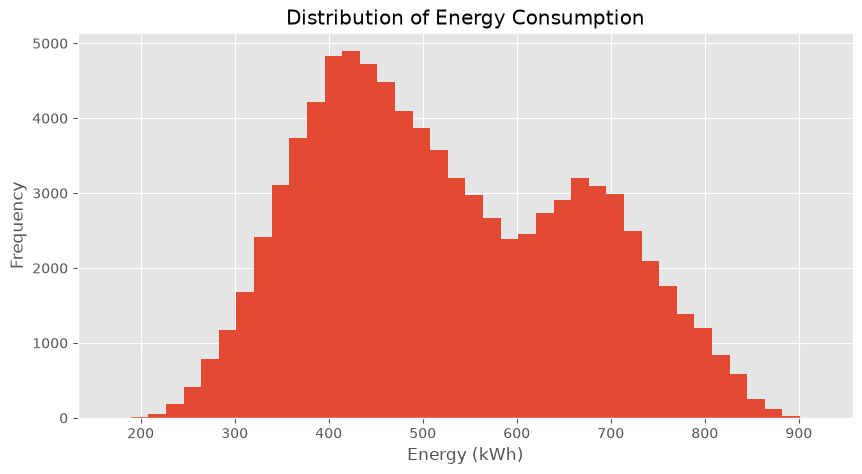

In [11]:
plt.figure(figsize=(10,5))

plt.hist(df["Energy_kWh"], bins=40)

plt.title("Distribution of Energy Consumption")

plt.xlabel("Energy (kWh)")

plt.ylabel("Frequency")

plt.show()

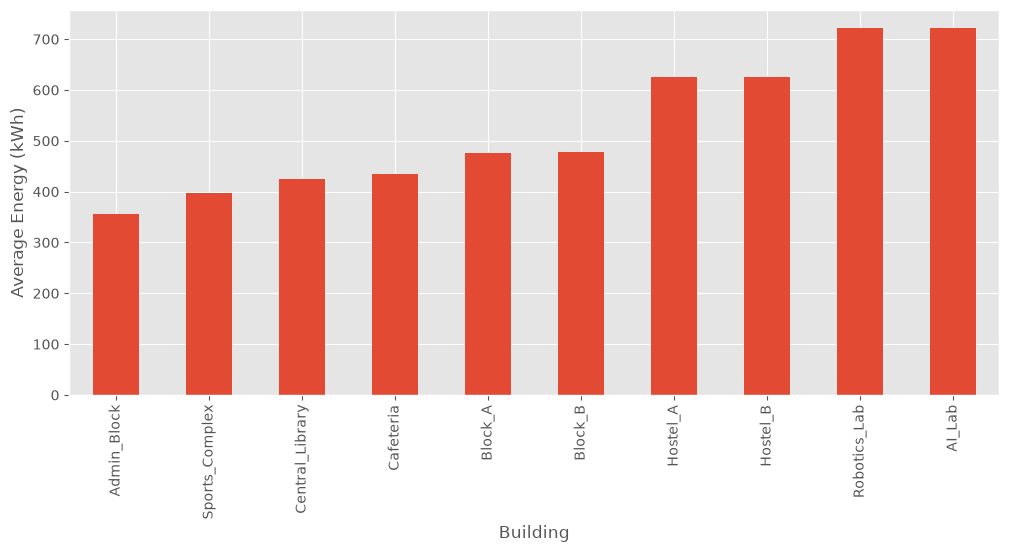

In [12]:
building_energy = (
    df.groupby("Building")["Energy_kWh"]
      .mean()
      .sort_values()
)

building_energy.plot(kind="bar", figsize=(12,5))

plt.ylabel("Average Energy (kWh)")

plt.show()

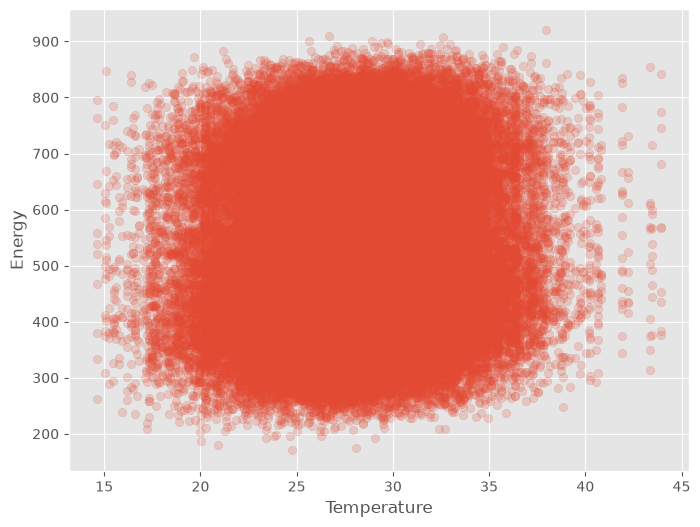

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Temperature"],
    df["Energy_kWh"],
    alpha=0.2
)

plt.xlabel("Temperature")

plt.ylabel("Energy")

plt.show()

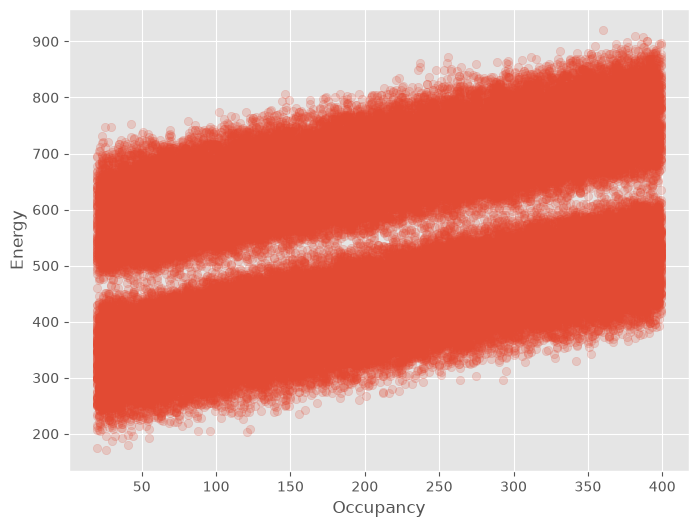

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Occupancy"],
    df["Energy_kWh"],
    alpha=0.2
)

plt.xlabel("Occupancy")

plt.ylabel("Energy")

plt.show()

In [15]:
numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

corr

,Energy_kWh,Temperature,Humidity,Occupancy,Holiday,Exam_Day,Weekend,Solar_Output,Equipment_Load,Carbon_Emission,Cost
Energy_kWh,1.000000,0.054267,0.001702,0.382702,-0.001381,0.004425,0.002791,-0.092946,0.579672,1.000000,1.000000
Temperature,0.054267,1.000000,0.004304,-0.002785,-0.002232,0.014415,0.003304,0.016942,-0.001273,0.054267,0.054267
Humidity,0.001702,0.004304,1.000000,0.004464,-0.000634,0.000291,-0.001919,0.004811,0.001783,0.001702,0.001702
Occupancy,0.382702,-0.002785,0.004464,1.000000,0.001435,0.007181,0.004375,-0.004335,-0.000539,0.382702,0.382702
Holiday,-0.001381,-0.002232,-0.000634,0.001435,1.000000,-0.013301,-0.004227,0.014896,-0.002134,-0.001381,-0.001381
Exam_Day,0.004425,0.014415,0.000291,0.007181,-0.013301,1.000000,0.027232,-0.005192,-0.000338,0.004425,0.004425
Weekend,0.002791,0.003304,-0.001919,0.004375,-0.004227,0.027232,1.000000,-0.001373,0.002324,0.002792,0.002791
Solar_Output,-0.092946,0.016942,0.004811,-0.004335,0.014896,-0.005192,-0.001373,1.000000,0.005327,-0.092946,-0.092946
Equipment_Load,0.579672,-0.001273,0.001783,-0.000539,-0.002134,-0.000338,0.002324,0.005327,1.000000,0.579672,0.579672
Carbon_Emission,1.000000,0.054267,0.001702,0.382702,-0.001381,0.004425,0.002792,-0.092946,0.579672,1.000000,1.000000


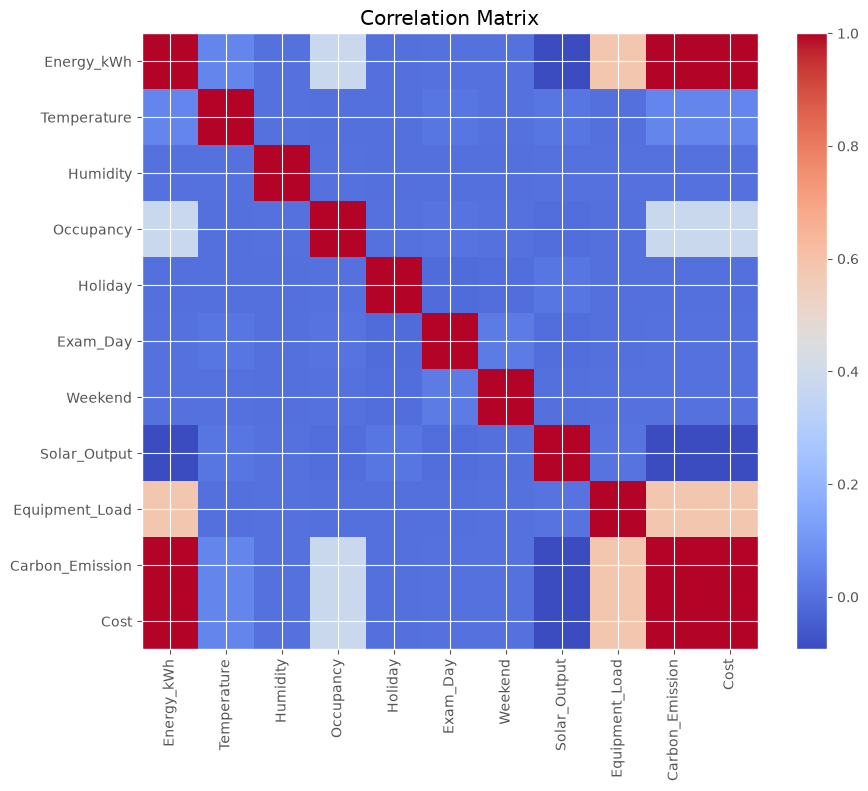

In [16]:
plt.figure(figsize=(10,8))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

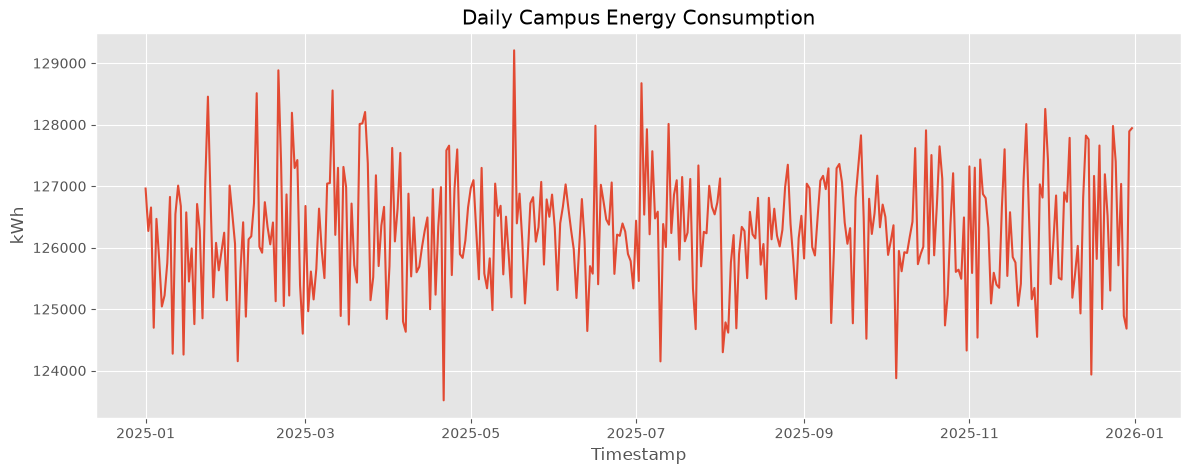

In [17]:
daily = (
    df.groupby(df["Timestamp"].dt.date)["Energy_kWh"]
      .sum()
)

plt.figure(figsize=(14,5))

daily.plot()

plt.title("Daily Campus Energy Consumption")

plt.ylabel("kWh")

plt.show()